In [35]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import date, timedelta
import seaborn as sns
sns.set()
plt.style.use('fivethirtyeight')

#calculate date range
today = date.today()
end_date = today.strftime("%Y-%m-%d")
d2= date.today() - timedelta(days=365)
start_date = d2.strftime("%Y-%m-%d")
print('today : ',today)
print('start_date : ',start_date)
print('end_date : ',end_date)

#data load
data = yf.download('AAPL', start=start_date, end=end_date, progress=False)
data['Date'] = data.index
data = data[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]
data.reset_index(drop=True, inplace=True)

today :  2023-09-15
start_date :  2022-09-15
end_date :  2023-09-15


In [36]:
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
246,2023-09-08,178.350006,180.240005,177.789993,178.179993,178.179993,65551300
247,2023-09-11,180.070007,180.300003,177.339996,179.360001,179.360001,58953100
248,2023-09-12,179.490005,180.130005,174.820007,176.300003,176.300003,90370200
249,2023-09-13,176.509995,177.300003,173.979996,174.210007,174.210007,84267900
250,2023-09-14,174.000000,176.100006,173.580002,175.740005,175.740005,60832500


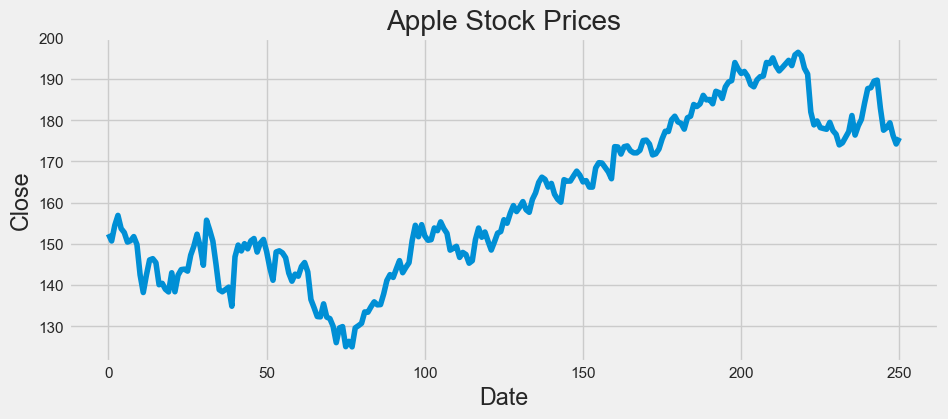

In [37]:
plt.figure(figsize=(10, 4))
plt.title("Apple Stock Prices")
plt.xlabel("Date")
plt.ylabel("Close")
plt.plot(data["Close"])
plt.show()

               Date      Open      High       Low     Close  Adj Close  \
Date       1.000000  0.859450  0.854866  0.862730  0.857561   0.861595   
Open       0.859450  1.000000  0.996923  0.997300  0.992969   0.993054   
High       0.854866  0.996923  1.000000  0.997159  0.997170   0.997112   
Low        0.862730  0.997300  0.997159  1.000000  0.997297   0.997366   
Close      0.857561  0.992969  0.997170  0.997297  1.000000   0.999962   
Adj Close  0.861595  0.993054  0.997112  0.997366  0.999962   1.000000   
Volume    -0.526790 -0.440095 -0.414693 -0.460811 -0.437123  -0.439577   

             Volume  
Date      -0.526790  
Open      -0.440095  
High      -0.414693  
Low       -0.460811  
Close     -0.437123  
Adj Close -0.439577  
Volume     1.000000  


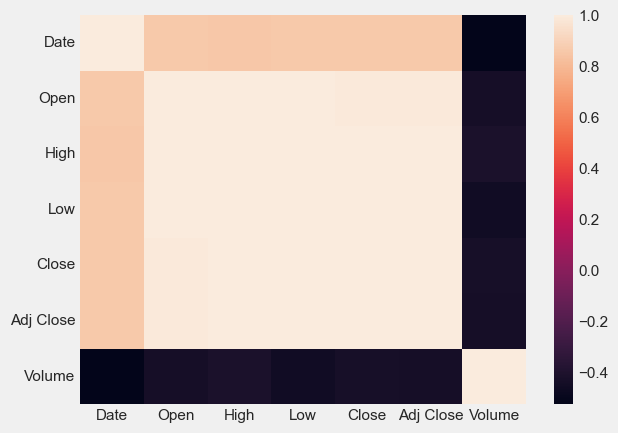

In [38]:
print(data.corr())
sns.heatmap(data.corr())
plt.show()

In [39]:
x = data[["Open", "High", "Low"]]
y = data["Close"]
x = x.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(xtrain, ytrain)
ypred = model.predict(xtest)
data = pd.DataFrame(data={"Predicted Rate": ypred})
print(data.head())

   Predicted Rate
0      168.539993
1      150.699997
2      174.199997
3      142.649994
4      148.309998


23/09/15 02:52:09 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1070023 ms exceeds timeout 120000 ms
23/09/15 02:52:09 WARN SparkContext: Killing executors is not supported by current scheduler.
